# Universe EDA — 20 ETF 를 하나의 지도 위에 (Phase 00.5)
기간 2019-01-03 ~ 2026-10-02 · 20 ETF × 1,902 일간 로그수익률 (FDR Close 그대로, 분배 소급조정 추정 · CL-04).
이 notebook 은 `analysis/scripts/universe_final.py` 를 실행해 **표(`reports/tables/universe_*.csv`)와 그림(`figures/universe/*.png`)을 결정적으로 재생성**한 뒤,
그림마다 4가지를 적는다: **WHAT THIS FIGURE MEASURES / WHAT WE SEE / WHY IT MATTERS FINANCIALLY / WHAT WE CANNOT CONCLUDE**.

세 가지 질문에 답한다: ① 20개가 어떻게 묶이는가 (§2) ② 언제 같이 움직이는가 (§3, §4) ③ 언제 관계가 깨지는가 (§3).
범위 밖: 뉴스·PELT·XGBoost·예측·매매. 여기 나오는 어떤 상관·동반도 **인과를 뜻하지 않는다**.

정의 고정: rolling baseline 은 모두 `shift(1)`. `rz3_D` = D 식 MAD(|r−trailing median| 의 rolling median, min 20), `rz3_A` = 창 내부 MAD(min 40), `q99` = ETF별 전체기간 |r| 99% 분위(look-ahead, 서술용), `abs3` = |r|>3%.
dedup = KOSPI200 동일 exposure 4종(069500·102110·122630·114800)을 1개로 셈. 261240 의 2019-03-14/15 (price_anomaly_unverified, CL-05) 는 상관·분포·충격 계산에서 제외(`Rt`), 변동성 표에는 raw/trim 병기.

In [1]:
import os, sys, subprocess, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
ROOT = Path.cwd()
while not (ROOT / "config" / "universe.csv").exists(): ROOT = ROOT.parent
r = subprocess.run([sys.executable, str(ROOT / "analysis/scripts/universe_final.py")], capture_output=True, text=True, cwd=ROOT)
assert r.returncode == 0, r.stderr[-2000:]
S = json.load(open(ROOT / "reports/tables/universe_run_summary.json", encoding="utf-8"))
def T(n, **k):
    d = pd.read_csv(ROOT / "reports/tables" / n, dtype={"a": str, "b": str}, **k)
    if k.get("index_col") == 0 and str(d.index.dtype).startswith("int"):
        d.index = d.index.astype(str).str.zfill(6)
    return d
F = lambda n: display(Image(filename=str(ROOT / "figures/universe" / n)))
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print(len(S["figures"]), "figures,", len(S["tables"]), "tables regenerated")

17 figures, 21 tables regenerated


## 0. 한글 폰트 점검
`src/kfont.py` 가 시스템 설치 `Noto Sans CJK KR` 을 고정하고 missing-glyph 경고 0 을 확인했다 (`figures/universe/00_korean_font_smoke.png`).

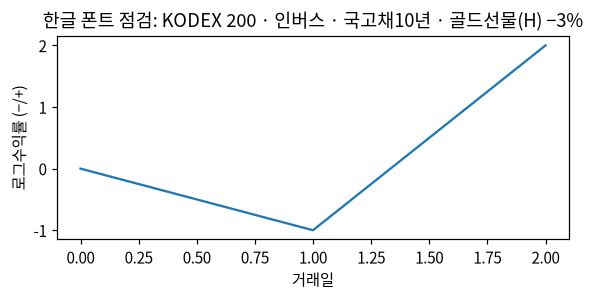

In [2]:
F("00_korean_font_smoke.png")

## 1. 같은 자 위에 놓기 — 스케일과 분포

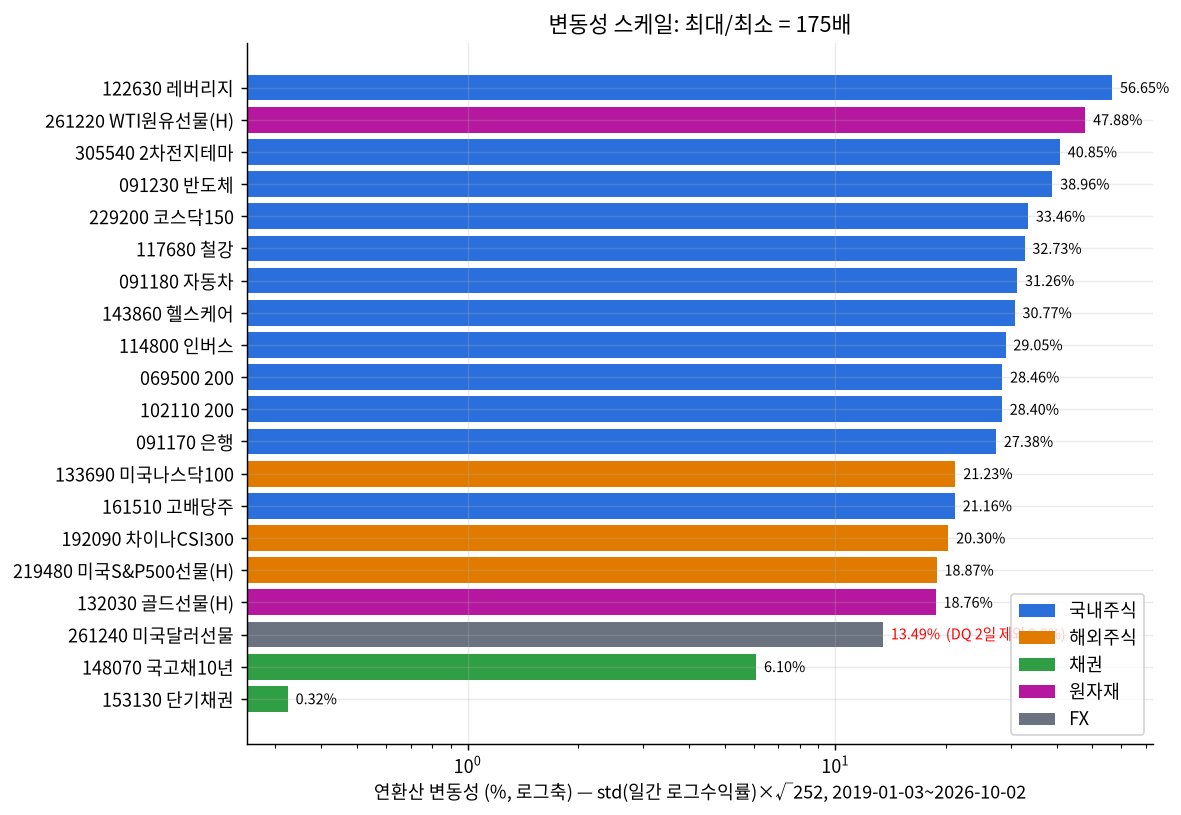

,ann_vol,ann_vol_trimdq,asset_scope
153130,0.0032,0.0032,bond
148070,0.0610,0.0610,bond
261240,0.1349,0.0892,fx
132030,0.1876,0.1876,commodity
219480,0.1887,0.1887,foreign_equity
192090,0.2030,0.2030,foreign_equity
161510,0.2116,0.2116,domestic_equity
133690,0.2123,0.2123,foreign_equity
091170,0.2738,0.2738,domestic_equity
102110,0.2840,0.2840,domestic_equity


In [3]:
F("01_vol_ranking.png"); T("universe_vol_rank.csv", index_col=0)

**WHAT THIS FIGURE MEASURES** — 전체기간 일간 로그수익률 표준편차×√252 (로그 x축), 색은 asset_scope. 표에 261240 DQ 2일 제외 값을 병기.

**WHAT WE SEE** — 153130 단기채권 0.32% ~ 122630 레버리지 56.6%, 최대/최소 ≈ **175배**. 국내주식 21~57%, 해외주식 19~21%, 국고채10년 6.1%, 금 18.8%, WTI 47.9%. 261240 달러선물은 raw 13.5% → DQ 2일 제외 **8.9%** (막대 옆 빨간 병기; 이틀이 vol 의 1/3 을 만든다).

**WHY IT MATTERS FINANCIALLY** — 같은 −3% 가 레버리지에서는 평범한 날, 채권·달러에서는 수년에 한 번이다. 단일 절대 threshold 는 경제적으로 다른 사건을 같은 이름으로 센다 (§4 abs3 177일 vs rz3 52일).

**WHAT WE CANNOT CONCLUDE** — 표준편차는 regime 평균이다 (2026 국면이 섞임, §1.2). 변동성 크기는 위험 *원인* 을 말하지 않으며, 레버리지의 vol 은 설계(2배)의 결과다.

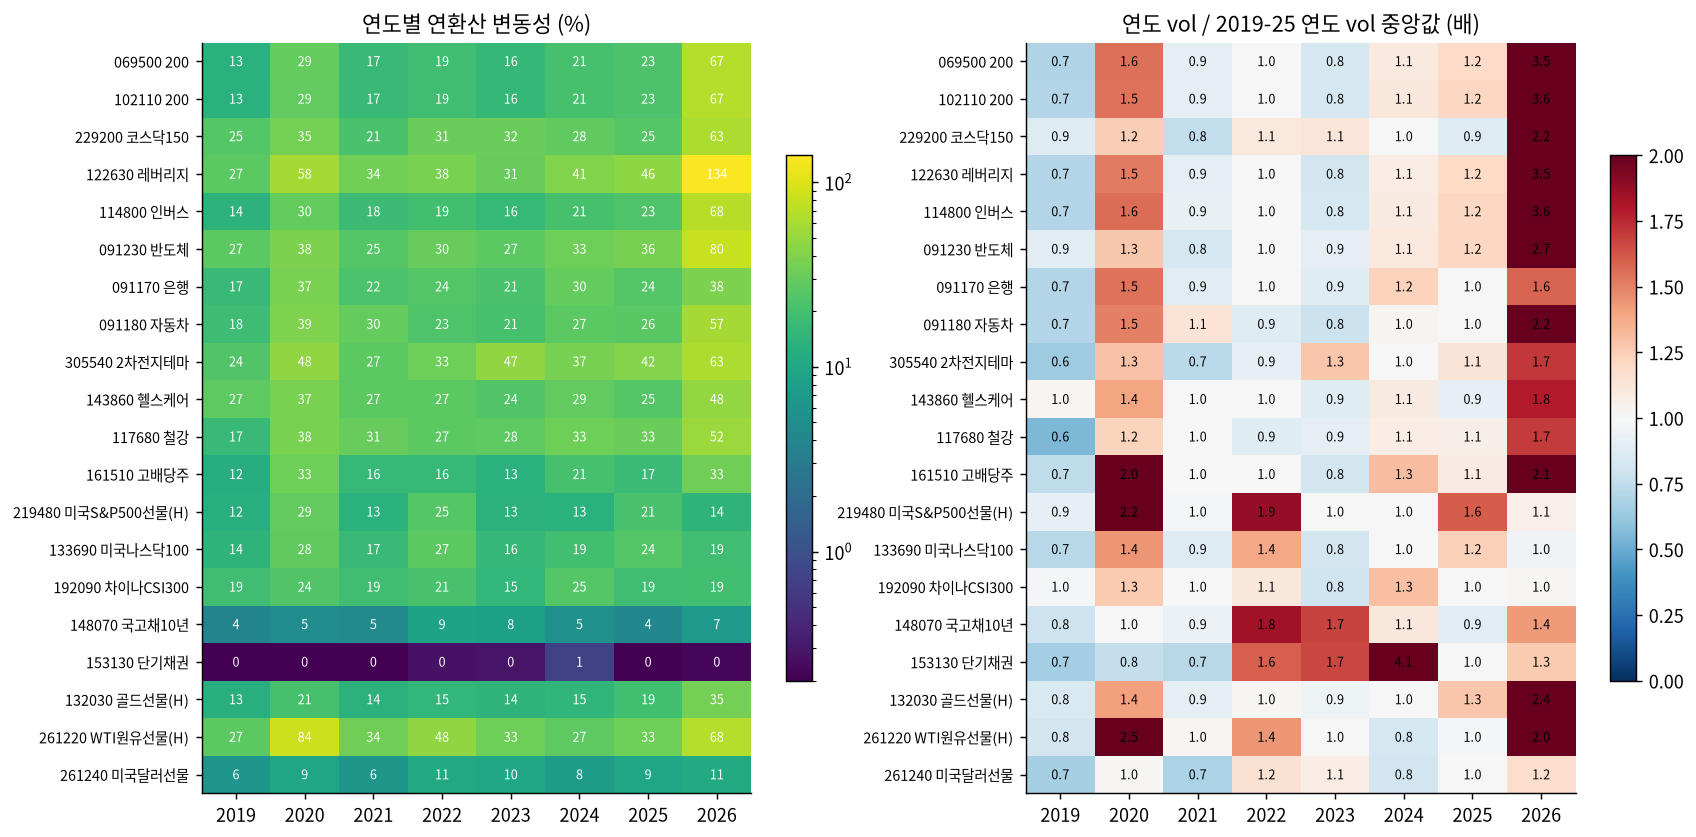

,vol_ratio_2026_vs_2019_25,asset_scope
153130,0.6558,bond
219480,0.7254,foreign_equity
133690,0.8733,foreign_equity
192090,0.9399,foreign_equity
148070,1.1522,bond
261240,1.2598,fx
091170,1.4822,domestic_equity
261220,1.5024,commodity
305540,1.6690,domestic_equity
143860,1.6970,domestic_equity


In [4]:
F("02_vol_year_heatmap.png"); T("universe_vol_ratio_2026.csv", index_col=0).sort_values("vol_ratio_2026_vs_2019_25")

**WHAT THIS FIGURE MEASURES** — 왼쪽: ETF×연도 연환산 vol (로그 색, 261240 DQ 2일 제외). 오른쪽: 각 연도 vol ÷ 그 ETF 의 2019–25 연도 vol 중앙값 (1 = 평소 수준, 붉을수록 확대).

**WHAT WE SEE** — 2026 에 KOSPI200 계열 4종 67~134% (069500 67.2%, 122630 134.1%), 반도체 80.2%. 표의 2026/2019-25 일간 sd 비율 (DQ 제외): 069500 **3.3× (자기 top3일 제외 2.9×)**, 반도체 2.55, 자동차 2.12 vs 해외주식 219480 **0.73**, 133690 0.87, 192090 0.94. 2020 은 universe 전체(원유 84.4%, 국내·해외 모두)가 붉다. 국고채10년은 2022 에 8.9% 로 두 배. **반례 (D, ROBUSTNESS_MATRIX)**: 금 132030 **2.21배 [1.39, 3.10]**, WTI 261220 1.50배, 달러 261240 **1.26 [1.04, 1.49]** (DQ 포함하면 0.80 으로 방향이 뒤집힘) — 2026 확대는 '국내주식 + 원자재' 이고 해외주식은 아니다.

**WHY IT MATTERS FINANCIALLY** — 2020 은 global risk-off(전 자산군), 2026 은 국내주식(+금) 국면. 전체기간 하나의 baseline 으로 정상 범위를 정하면 2026 국내주식이 기준을 끌어올린다 (CL-30).

**WHAT WE CANNOT CONCLUDE** — 2026 은 1~9월 184 거래일이라 연도 비교의 표본이 작다. 확대 원인(정책·업종·수급)은 OHLCV 만으로 식별 불가. 표는 DQ 제외값 (raw 기준이면 261240 2019 vol 28.9%).

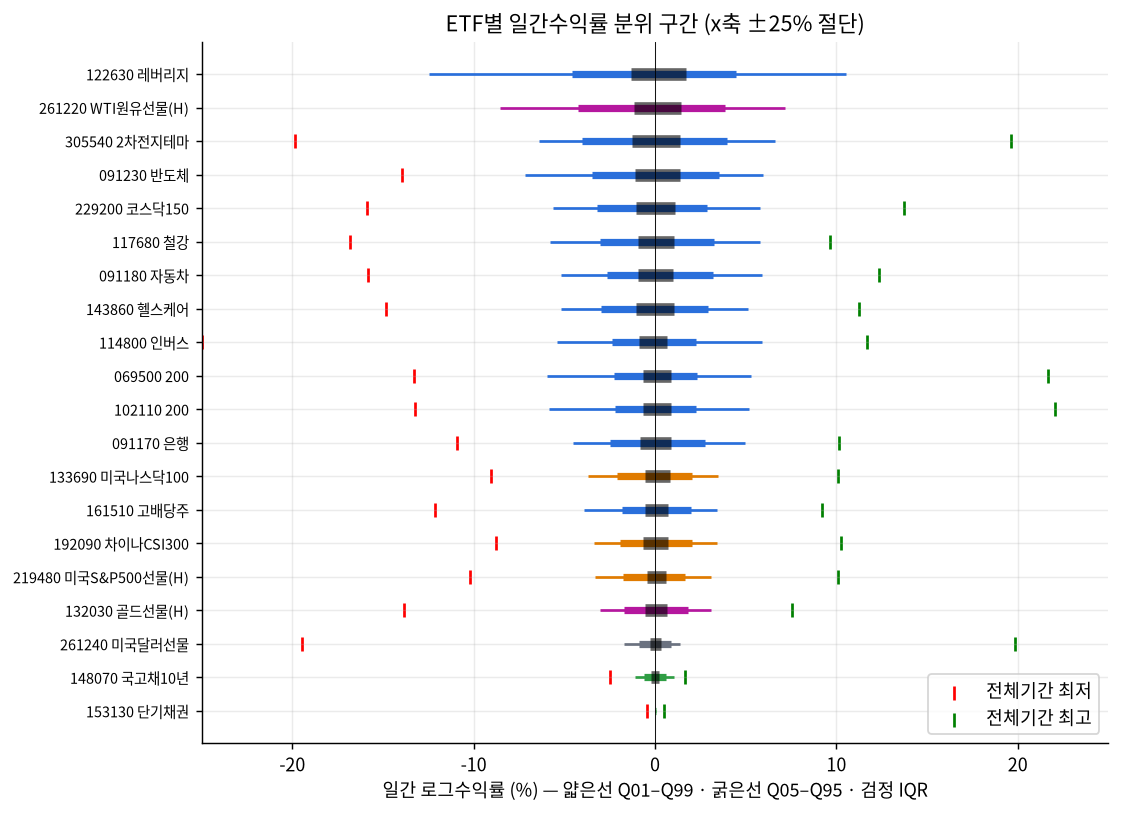

In [5]:
F("03_quantile_interval.png")

**WHAT THIS FIGURE MEASURES** — ETF별 일간수익률 분위 구간: 얇은 선 Q01–Q99, 굵은 선 Q05–Q95, 검정 IQR, 빨강/초록 tick = 전체기간 최저/최고.

**WHAT WE SEE** — Q01–Q99 가 153130 [−0.02%, +0.05%] 에서 122630 [−12.4%, +10.5%] 까지. 대부분 주식형은 하방 Q01 이 상방 Q99 보다 길다 (069500 −5.97/+5.29). 최저 tick 이 Q01 의 2~3배 밖에 있는 ETF(WTI, 레버리지, 달러선물)는 꼬리가 몇 날에 의해 정해진다.

**WHY IT MATTERS FINANCIALLY** — 극단의 *크기* 는 분위로, *모양*(비대칭)은 Q01/Q99 비로 읽는다. 하방 꼬리가 긴 자산은 같은 vol 이라도 손실 꼬리 위험이 크다.

**WHAT WE CANNOT CONCLUDE** — 분위는 전체기간 pooled 값이라 시간 변화를 숨긴다. 최저/최고 tick 의 개별 날짜는 DQ 확인 전(261240 2019-03) 경제적 사건으로 읽으면 안 된다.

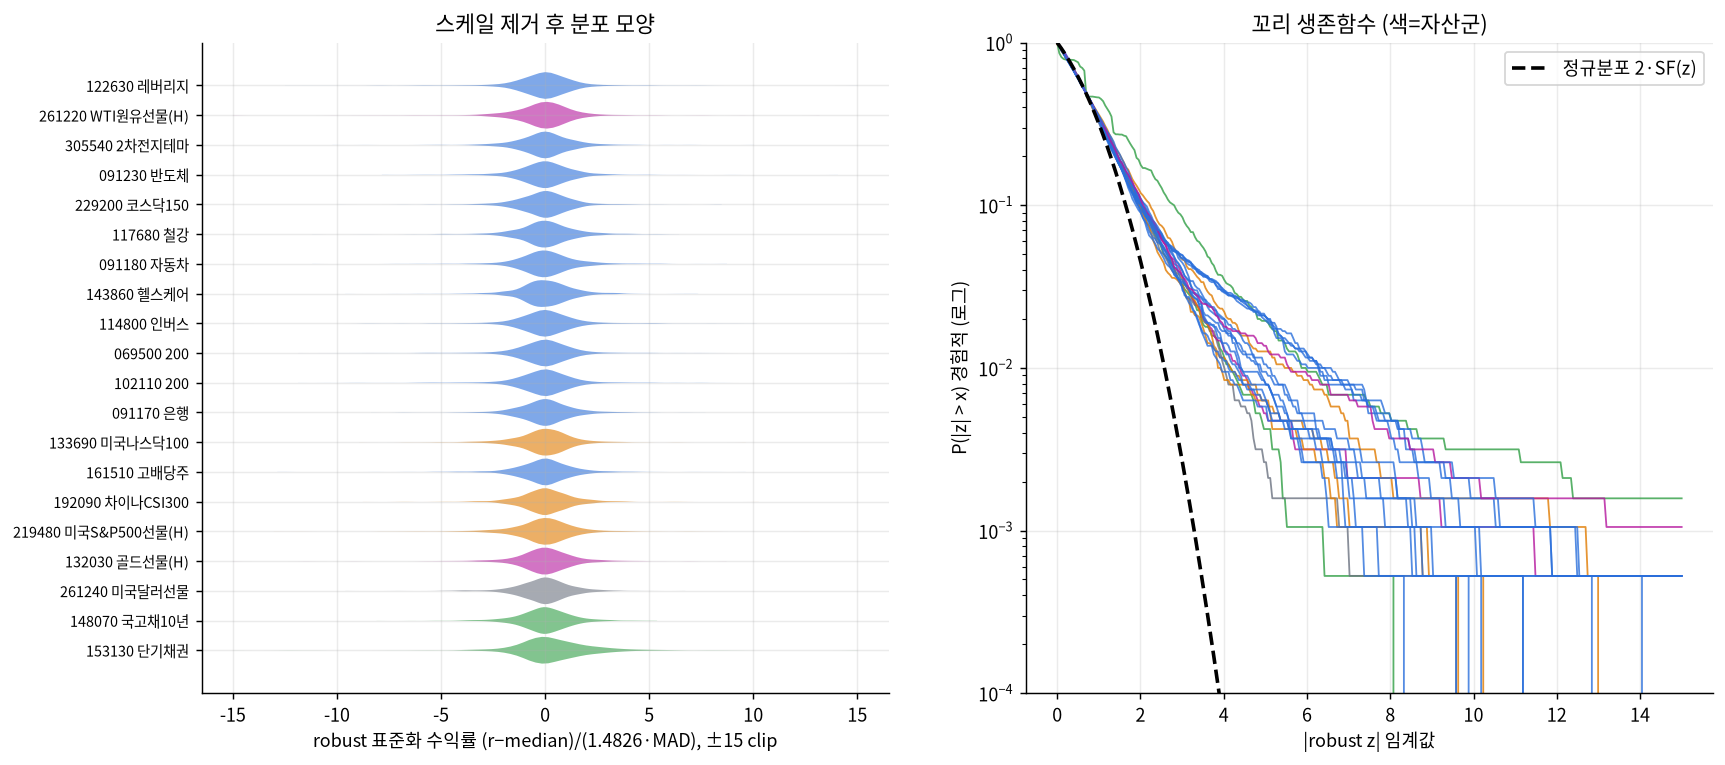

In [6]:
F("04_distribution_standardized.png")

**WHAT THIS FIGURE MEASURES** — 스케일을 제거한 분포 모양. 왼쪽: robust z = (r−median)/(1.4826·MAD) 의 violin (±15 clip). 오른쪽: P(|z|>x) 경험적 생존함수 (로그 y) 와 정규분포 기준선(검은 점선).

**WHAT WE SEE** — 모든 ETF 곡선이 정규 기준선보다 훨씬 위에 있다: 정규에서 P(|z|>5) ≈ 5.7e-7 이지만 20종 모두 1e-3 이상. 곡선이 가장 높은 쪽은 153130(틱 이산성, 0수익률 16.8% → MAD 작음, CL-25) 과 레버리지·국내 지수형.

**WHY IT MATTERS FINANCIALLY** — robust z 의 '|z|>3' 이 의미하는 희소성은 ETF마다 다르다. z 는 통계적 극단이지 경제적 크기가 아니다 — 153130 의 −0.47% 가 z −34 (CL-25).

**WHAT WE CANNOT CONCLUDE** — 전체기간 MAD 로 표준화한 것이라 국면별 꼬리(조건부 분포)는 보여주지 않는다. fat tail 이 '정규 대비' 임을 보일 뿐, 어떤 꼬리 분포족이 맞는지는 검정하지 않았다.

## 2. 어떻게 묶이는가 — taxonomy vs 통계적 군집

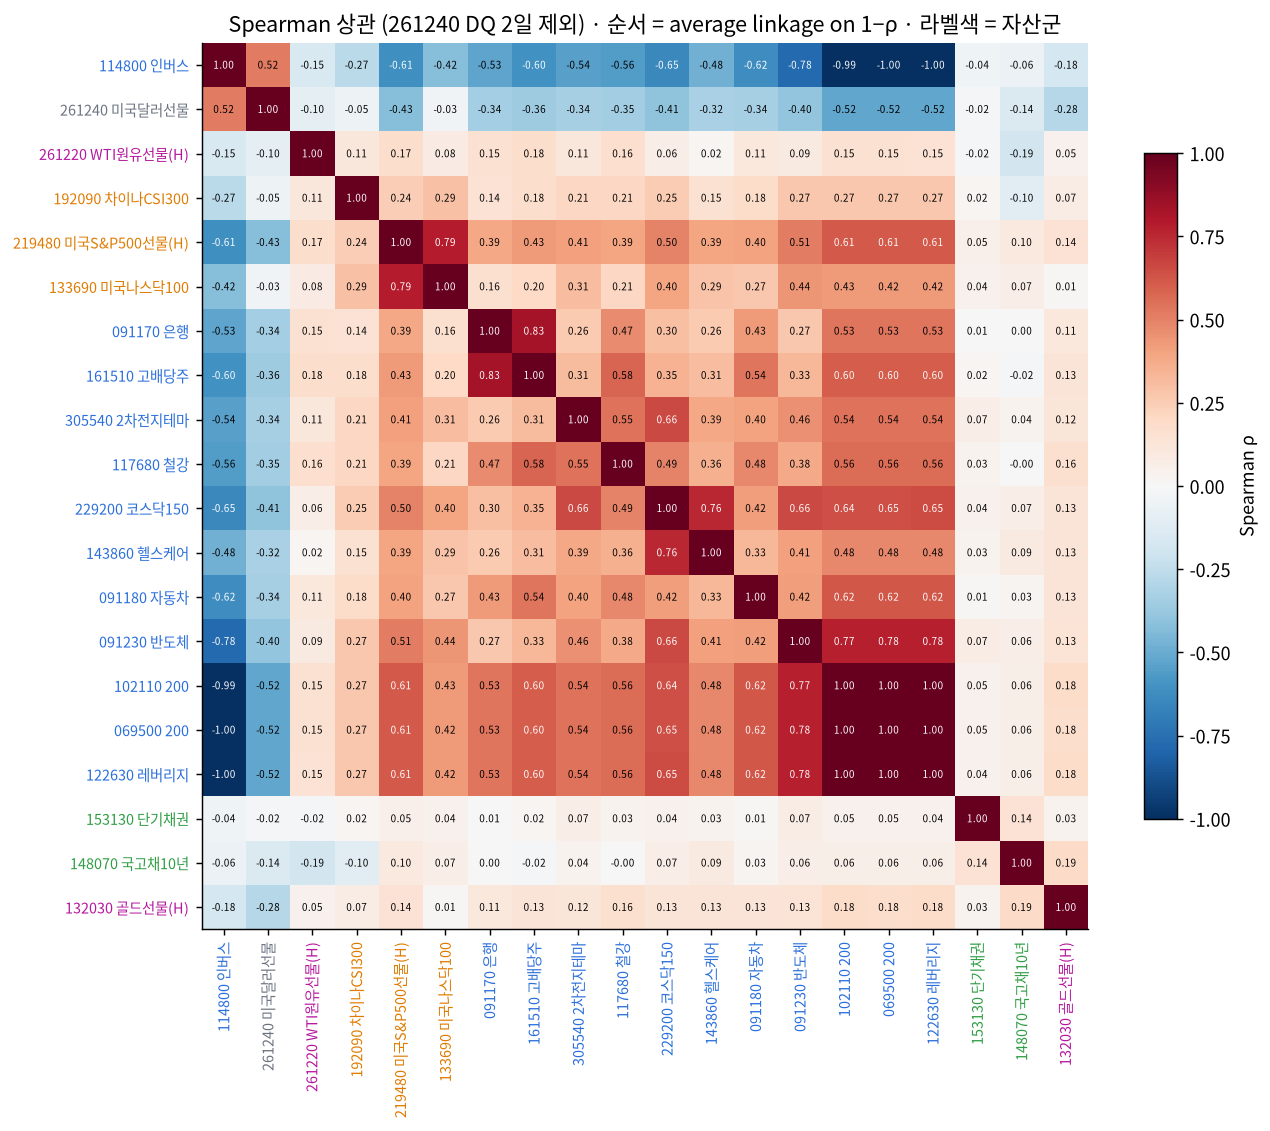

In [7]:
F("05_corr_spearman_clustered.png")

**WHAT THIS FIGURE MEASURES** — 20×20 Spearman ρ (261240 DQ 2일 제외), 행·열 순서는 1−ρ average linkage 의 leaf 순서, 라벨 색 = asset_scope.

**WHAT WE SEE** — ① KOSPI200 블록: 069500·102110·122630 ρ = 1.00, 114800 −0.99~−1.00 (기계적 복제/부호변환). ② 국내 업종 블록 0.26~0.78. ③ 경험적 peer: 143860 헬스케어–229200 코스닥150 **0.76** vs –069500 0.48; 161510 고배당–091170 은행 **0.83** vs –069500 0.60; 305540 2차전지–117680 철강 0.55 > –091230 반도체 0.46. ④ 채권·금·단기채는 모든 주식과 |ρ|<0.2. ⑤ 261240 달러선물은 국내주식과 −0.35~−0.52, 114800 과 +0.52.

**WHY IT MATTERS FINANCIALLY** — 이름(업종 라벨)보다 실제 factor 노출(성장/코스닥, 금융/가치)이 움직임을 결정한다. peer 는 브랜드·라벨이 아니라 데이터로 정해야 한다.

**WHAT WE CANNOT CONCLUDE** — 높은 ρ ≠ 같은 경제적 원인. 구성종목 중복(헬스케어 ETF 의 코스닥 바이오 비중 등)을 holdings 로 확인하지 않았다. 해외 ETF 는 거래시간 비동기라 동일일 ρ 가 과소추정될 수 있다 (CL-15).

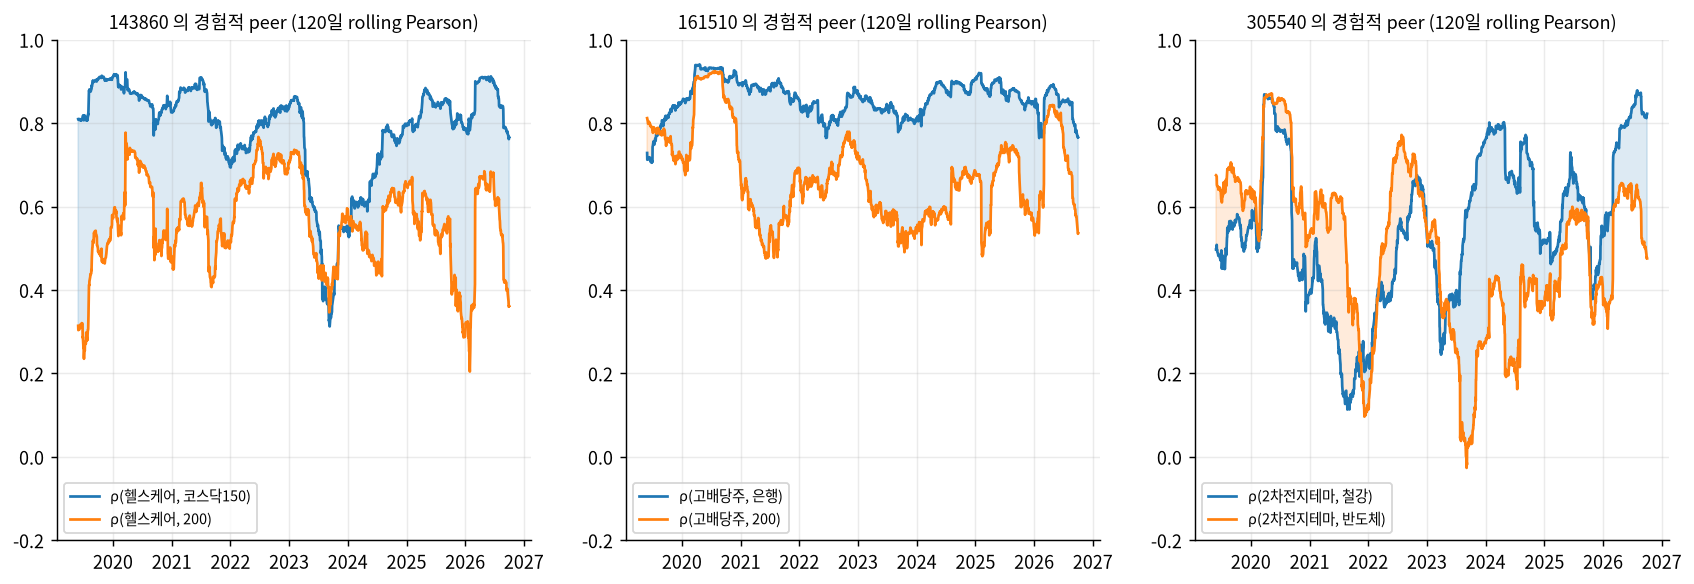

,ci_lo,median,ci_hi
"rho(143860,229200)-rho(143860,069500)",0.2312,0.2770,0.3199
"rho(161510,091170)-rho(161510,069500)",0.1793,0.2209,0.2651


In [8]:
F("14_empirical_peer_rolling.png"); T("universe_claim_bootstrap_ci.csv", index_col=0)

**WHAT THIS FIGURE MEASURES** — 세 ETF 의 '라벨 peer' vs '경험적 peer' 120일 rolling Pearson. 표: 20일 block bootstrap(300회, seed 20261004) Spearman ρ 차이의 95% CI.

**WHAT WE SEE** — 헬스케어: ρ(코스닥150) − ρ(KOSPI200) 점추정 **+0.275**, 95% CI [0.23, 0.32], rolling 상 거의 전 기간 위. 고배당: 점추정 **+0.227** [0.18, 0.27]. rolling Δ>0 비율(60D/120D): 헬스케어 0.96/0.95 (2023-08-30 일시 역전 −0.21), 고배당 0.95/0.97, 2차전지(철강−반도체) **0.53/0.53** → 안정적 peer 없음. 2차전지: 2019-21 은 반도체(0.66) > 철강(0.54), 2022-25 철강 0.57 > 반도체 0.42, 2026 철강 0.82 > 반도체 0.54 → **국면 의존** (CL-17 HOLD 유지).

**WHY IT MATTERS FINANCIALLY** — 헬스케어·고배당의 경험적 peer 는 전 기간 안정적이라 benchmark 대안으로 쓸 근거가 있다. 2차전지–철강은 고정 관계가 아니다.

**WHAT WE CANNOT CONCLUDE** — CI 는 block 길이 20 고정. 2차전지–철강 동조의 원인(원자재 사이클·소재 테마)은 미검증.

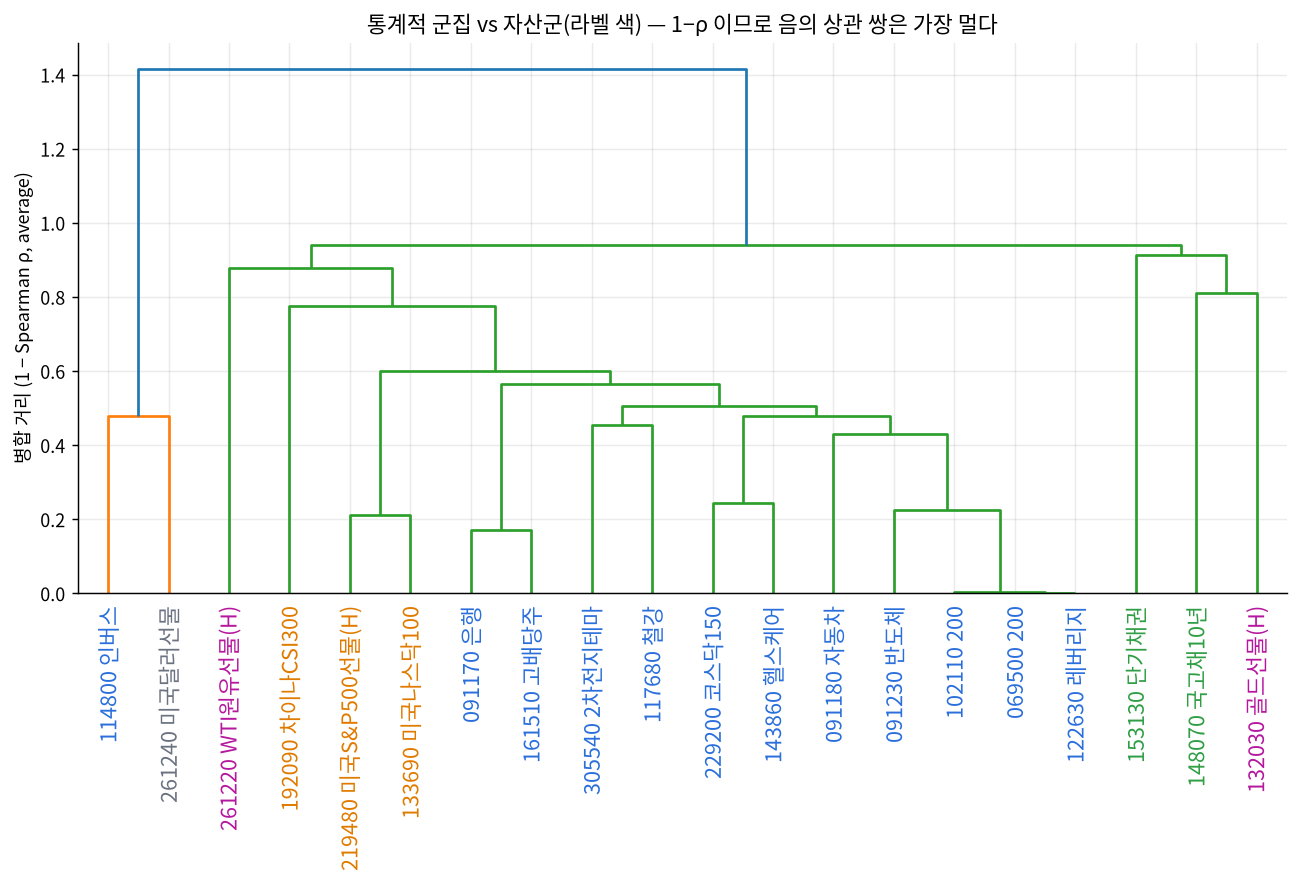

,avg_k3,avg_k5,avg_k8,asset_scope,category
069500,2,2,3,domestic_equity,broad_market
102110,2,2,3,domestic_equity,broad_market
229200,2,2,3,domestic_equity,broad_market
122630,2,2,3,domestic_equity,leveraged_inverse
114800,1,1,1,domestic_equity,leveraged_inverse
091230,2,2,3,domestic_equity,sector
091170,2,2,3,domestic_equity,sector
091180,2,2,3,domestic_equity,sector
305540,2,2,3,domestic_equity,theme
143860,2,2,3,domestic_equity,sector


In [9]:
F("06_dendrogram.png"); T("universe_clusters.csv", index_col=0)

**WHAT THIS FIGURE MEASURES** — 1−Spearman ρ average linkage 덴드로그램. 거리 1−ρ 는 음의 상관 쌍을 '가장 먼' 쌍으로 만든다 (부호 정보 내장).

**WHAT WE SEE** — k=3: 주식형 14종(국내 11 + 해외 3) + WTI 가 한 덩어리, 114800 인버스·261240 달러 가 한 덩어리, 채권 2·금 가 한 덩어리. 114800 과 261240 이 같은 군집 (signed 거리 k=5: True). 1−|ρ| 로 바꾸면 114800 은 069500 과 같은 군집 → **부호 artifact** (CL-14).

**WHY IT MATTERS FINANCIALLY** — 통계 군집은 '시장과 반대로 움직인다' 를 묶을 뿐, 인버스(지수 숏)와 달러(원화약세)는 경제적으로 다른 exposure 다. economic taxonomy 와 statistical cluster 는 다르게 쓰여야 한다.

**WHAT WE CANNOT CONCLUDE** — 군집 수 k, linkage, 거리 정의에 따라 경계가 바뀐다 (D-015). 이 덴드로그램 하나로 '업종 간 분화가 없다' 고 결론 내리면 안 된다 — 거리 척도가 시장 공통 factor 에 지배된다.

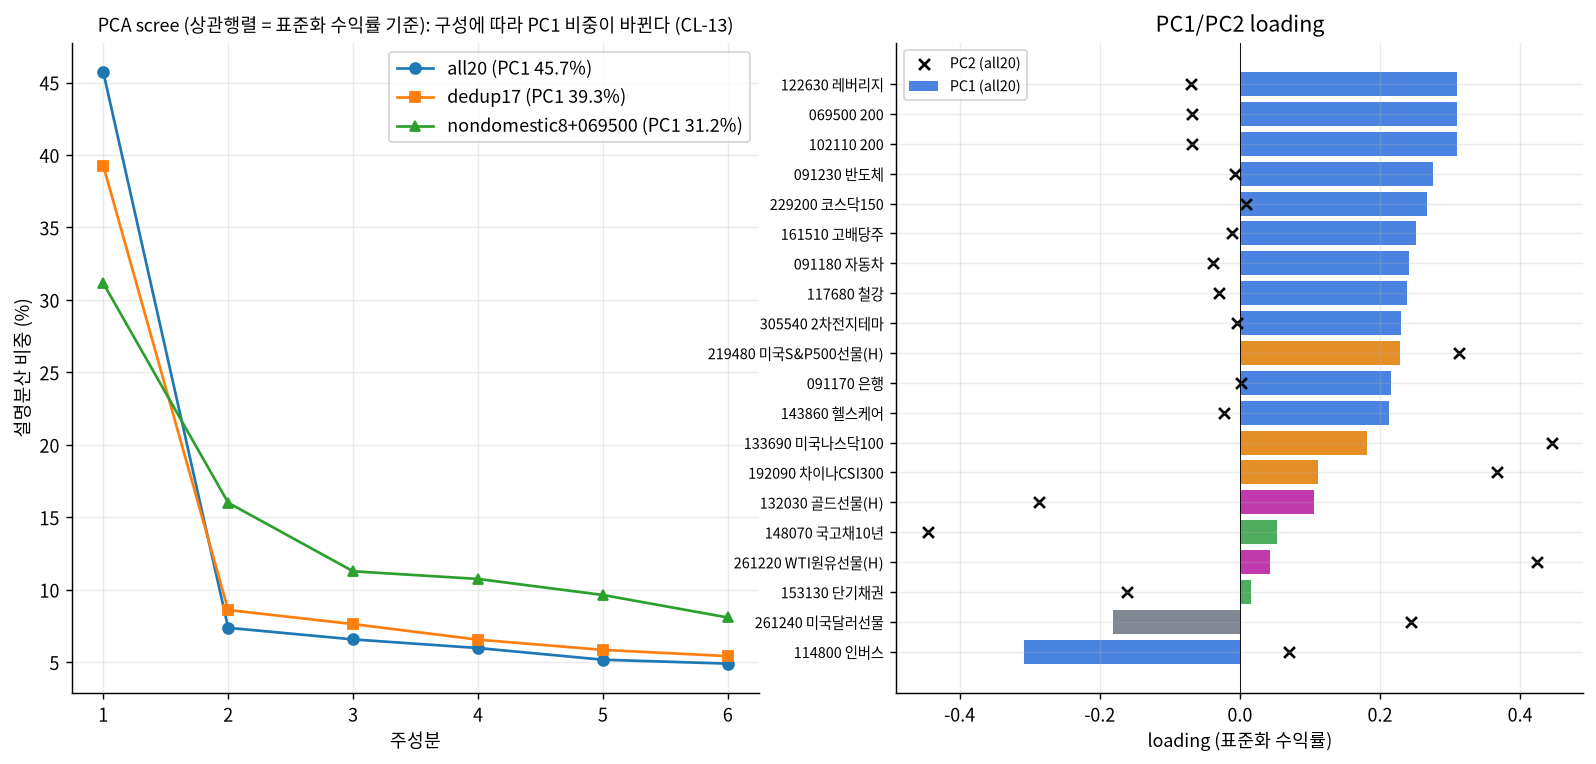

,all20,dedup17,nondomestic8+069500
PC1,0.4572,0.3927,0.3115
PC2,0.0737,0.0860,0.1600
PC3,0.0657,0.0763,0.1128
PC4,0.0598,0.0656,0.1075
PC5,0.0517,0.0585,0.0964
PC6,0.0490,0.0542,0.0809


In [10]:
F("09_pca_scree_loading.png"); T("universe_pca_evr.csv", index_col=0)

**WHAT THIS FIGURE MEASURES** — **상관행렬 기준** PCA (표준화 수익률; 공분산 기준이면 PC1 0.565, rank 기준이면 0.430 — D 0122, `analysis/robustness/d0122/`). 왼쪽 scree 를 세 universe 구성으로 비교: all20 / dedup17 (102110·122630·114800 제외) / 비국내 8종+069500. 오른쪽 all20 의 PC1(막대)·PC2(×) loading.

**WHAT WE SEE** — PC1 비중 all20 **45.7%** → dedup17 **39.3%** → 비국내+069500 31.2%. PC1 = 국내주식 공통 factor (KOSPI200 3종 0.31, 114800 −0.31). PC2 는 해외·원자재(133690 0.45, 261220 0.42, 192090 0.37, 219480 0.31) vs 채권·금(148070 −0.45, 132030 −0.29) 축.

**WHY IT MATTERS FINANCIALLY** — 같은 exposure 를 여러 번 넣으면 '시장 factor 가 강하다' 가 과장된다. PC1 비중은 universe 의 성질이 아니라 **구성의 함수** (CL-13).

**WHAT WE CANNOT CONCLUDE** — PC 는 회전 불변이 아니고 해석 라벨(해외/원자재 축)은 사후 해석이다. 전체기간 PCA 는 국면 변화를 평균한다.

## 3. 언제 같이 움직이고, 언제 관계가 깨지는가

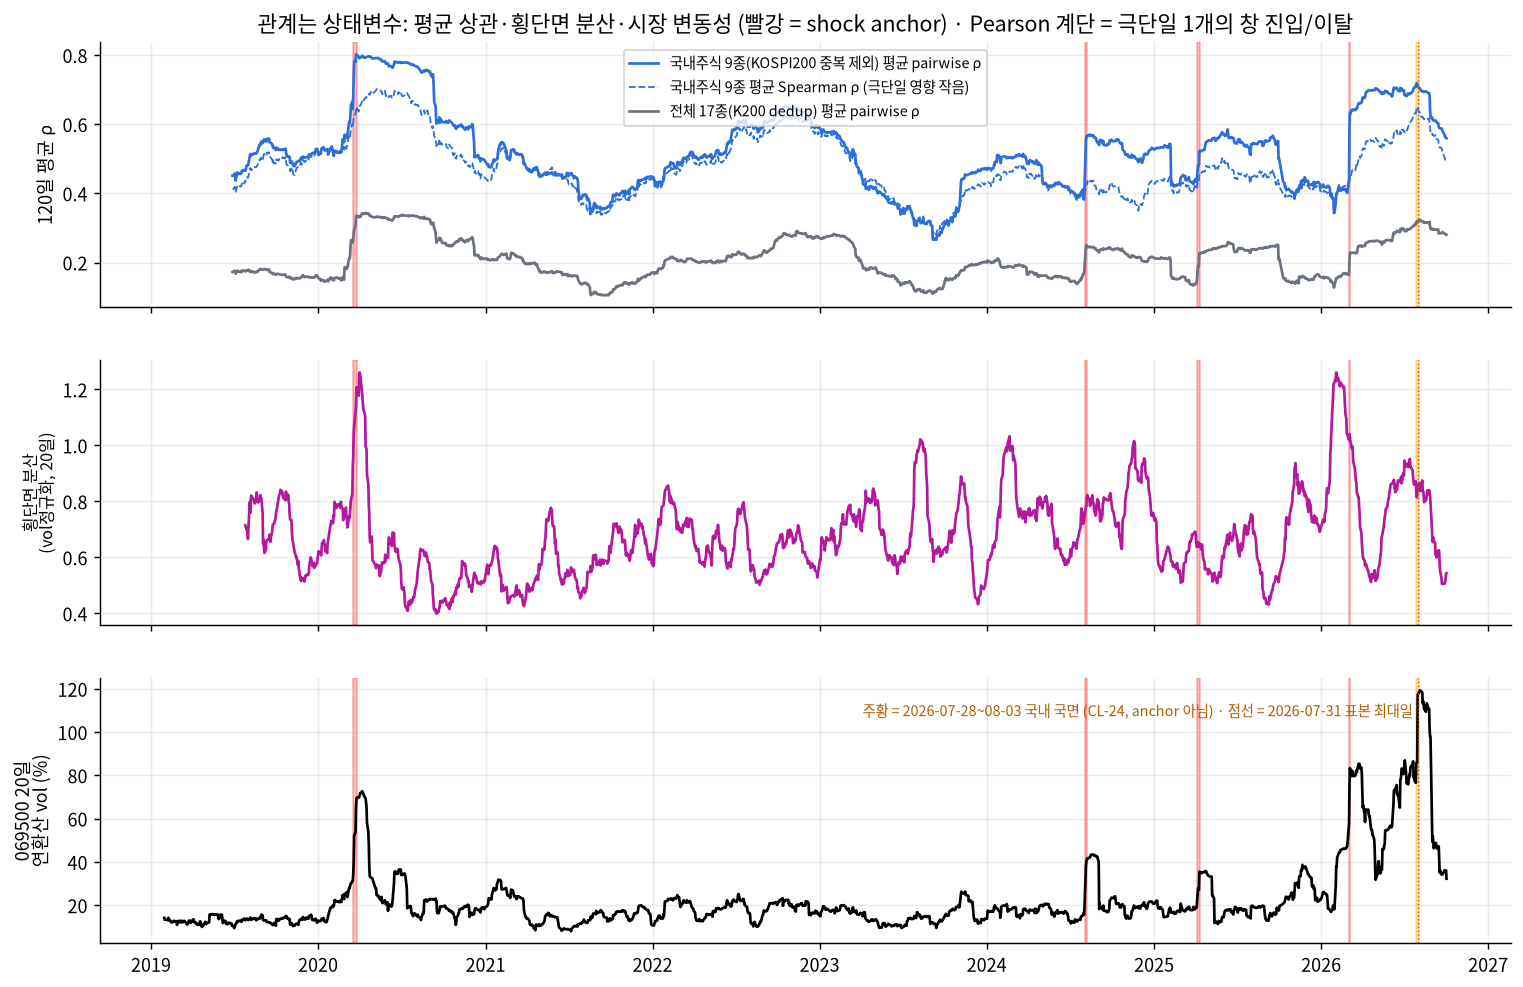

In [11]:
F("08_rolling_corr_dispersion.png")

**WHAT THIS FIGURE MEASURES** — 상단: 120일 rolling 평균 pairwise Pearson (국내주식 9종 / 전체 17종, KOSPI200 중복 제외) + 국내 9종 Spearman (파란 점선). 주황 음영 = 2026-07-28~08-03 국내 국면 (CL-24), 점선 = 2026-07-31 표본 최대일. 중단: 각 ETF 를 자기 직전 250일 vol 로 나눈 뒤의 횡단면 표준편차(20일 평균). 하단: 069500 20일 연환산 vol. 빨강 = shock anchor.

**WHAT WE SEE** — 국내주식 평균 ρ 중앙값 0.51, 최저 **0.27 (2023-09-11)**, 최고 **0.80 (2020-03-24)**. 전체 17종은 0.11(2021-09) ~ 0.34(2020-04). 120일 평균 ρ 와 120일 평균 시장 vol 의 Spearman 상관 = **0.60** — 변동성이 높은 국면일수록 동조가 강하다. **Pearson 선의 계단은 단일 극단일 효과다**: 2024-08-05 하루가 창에 들어오며 국내 9종 Pearson 평균이 0.416 → 0.552 (+0.136) 로 뛰지만 Spearman 은 0.403 → 0.417 (+0.014) 이고, 120일 뒤 그 날이 창에서 빠질 때 Pearson 이 다시 떨어진다 (D 0122). Spearman 범위 0.28 (2023-09-13) ~ 0.70 (2020-05-11).

**WHY IT MATTERS FINANCIALLY** — 분산효과는 가장 필요할 때(충격기) 줄어든다. 상관 수준 자체가 시장 상태를 기술하는 변수다 (상관 상승 = 공통 factor 지배, 하락 = 업종 분화).

**WHAT WE CANNOT CONCLUDE** — 120일 창은 충격 후 수개월 동안 상관을 높게 유지시킨다 (window lag). vol 과 상관의 동시 상승은 Pearson 의 vol-편향(Forbes-Rigobon)을 포함할 수 있어 '진짜 연결 증가' 와 구분하지 않았다.

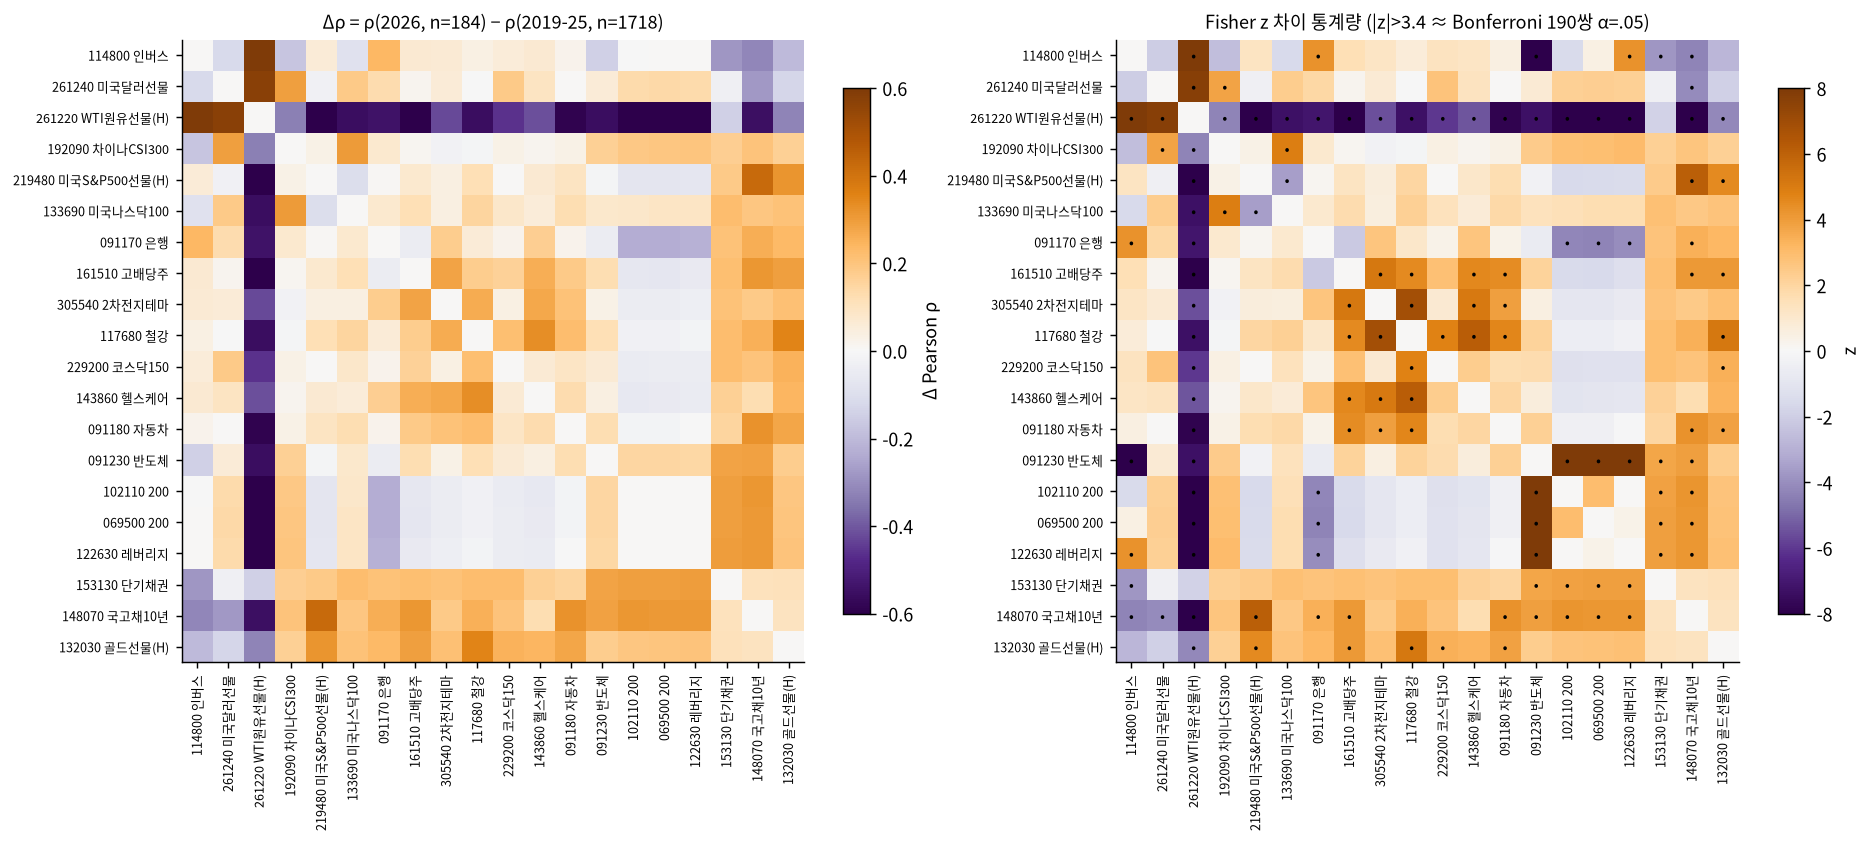

,a,b,rho_2019_25,rho_2026,fisher_z_stat
0,219480,261220,0.3284,-0.6115,-13.4652
1,069500,091230,0.7993,0.9478,9.1267
2,102110,091230,0.7980,0.9470,9.0730
3,114800,261220,-0.2858,0.3710,8.7461
4,161510,261220,0.3001,-0.3545,-8.7033
5,122630,261220,0.2834,-0.3693,-8.6875
6,114800,091230,-0.7988,-0.9438,-8.6576
7,069500,261220,0.2875,-0.3626,-8.6453
8,102110,261220,0.2848,-0.3643,-8.6335
9,122630,091230,0.8019,0.9442,8.5906


In [12]:
F("07_period_diff_corr.png"); T("universe_corr_period_diff.csv").head(12)

**WHAT THIS FIGURE MEASURES** — 2026 (n=184) 과 2019-25 (n=1718) 의 Pearson ρ 차이. 왼쪽 Δρ, 오른쪽 Fisher z 차이 통계량 (•= |z|>3.4, 190쌍 Bonferroni α=0.05 근사; 독립 관측 가정).

**WHAT WE SEE** — |z|>3.4 쌍: **KOSPI200 중복 제외 44/136 (32%)** (raw 60/190, 증가 36 / 감소 24). 최대 변화: WTI 261220–S&P500(H) 219480 **+0.33 → −0.61** (z −13.5), WTI–069500 +0.29 → −0.36. 반도체–KOSPI200 0.80 → **0.95** (z +9.1). 즉 2026 은 (a) 국내 반도체–지수 결합 강화, (b) 원유–주식 부호 반전 두 방향이 동시에.

**WHY IT MATTERS FINANCIALLY** — 상관 구조는 고정 파라미터가 아니다. 2019-25 로 추정한 hedge/peer 관계가 2026 에는 반대 부호일 수 있다 (CL-31).

**WHAT WE CANNOT CONCLUDE** — 일간수익률의 자기상관·이분산 때문에 Fisher z 의 독립 가정은 낙관적이다(D-024 block bootstrap 은 방향 동일). 원인 해석(유가 공급 충격 등)은 범위 밖.

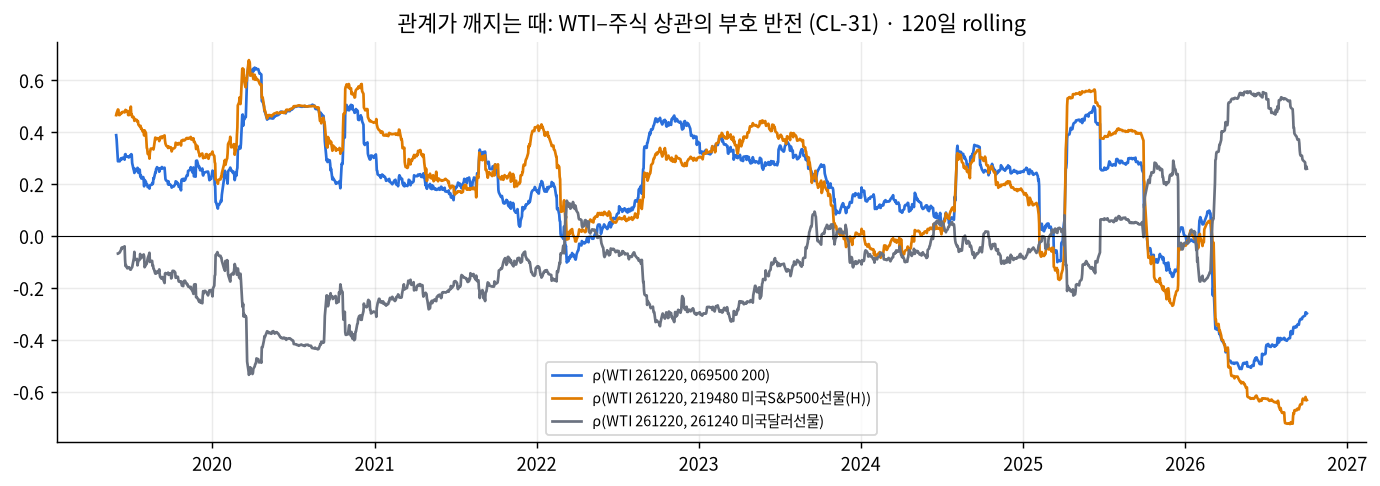

In [13]:
F("15_wti_equity_sign_flip.png")

**WHAT THIS FIGURE MEASURES** — WTI 261220 과 069500 / 219480 / 261240 의 120일 rolling Pearson.

**WHAT WE SEE** — 2019-25 대부분 WTI–주식 ρ 는 양(+0.1~+0.5, 위험자산 동조), 2026 진입 후 −0.4~−0.6 으로 반전. 동시에 WTI–달러(회색) 는 Pearson −0.295 (2019-21) → −0.084 (22-25) → **+0.402 (2026)**: 2026 에 WTI 가 위험자산 축에서 달러 축으로 이동했다.

**WHY IT MATTERS FINANCIALLY** — 원유가 '위험자산' 처럼 움직이는 국면과 '주식에 반대' 로 움직이는 국면이 있다. 원자재를 주식의 고정 보완/대체물로 보면 안 된다.

**WHAT WE CANNOT CONCLUDE** — 2026 반전의 원인, 지속성 모두 미확인 (184일). 선물 롤·환헤지(H) 효과를 분리하지 않았다.

## 4. 충격 — 정의, 동반, 부호

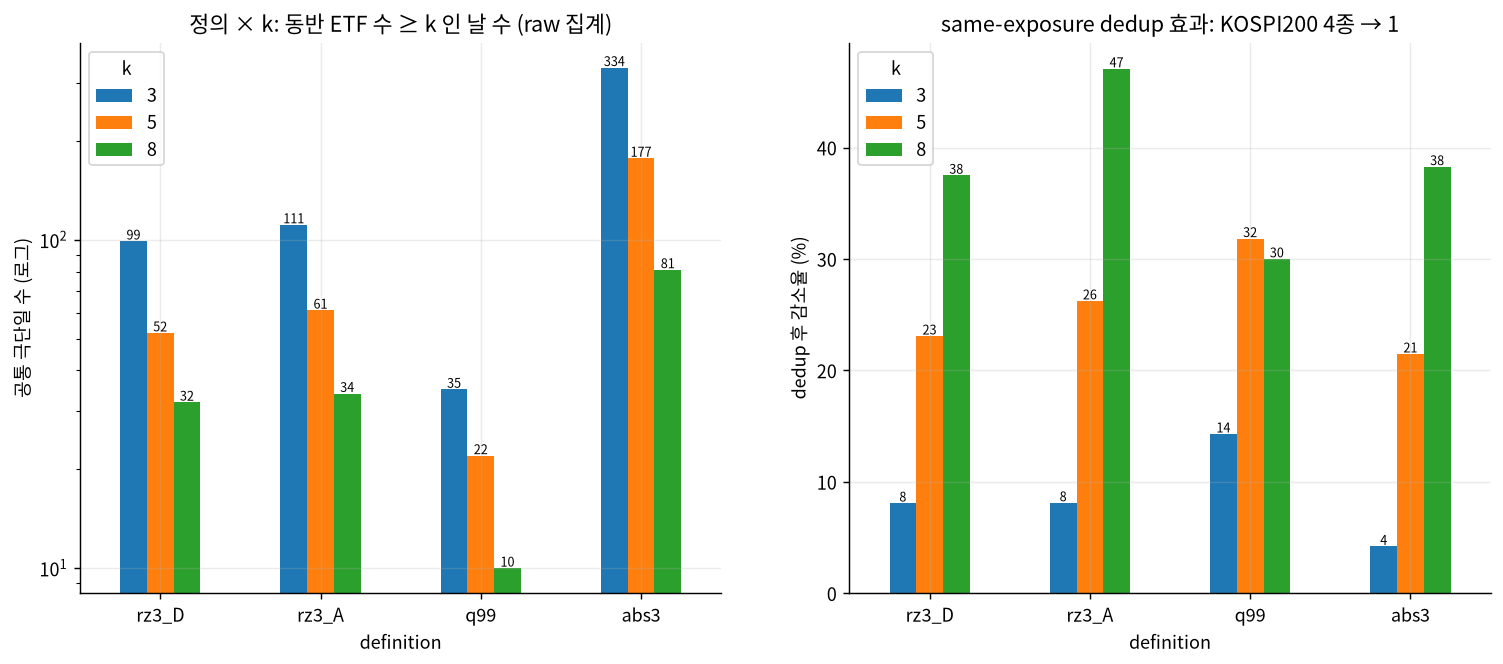

n_days          n_days_dedup         
k               3    5   8            3    5   8
definition                                      
abs3          334  177  81          320  139  50
q99            35   22  10           30   15   7
rz3_A         111   61  34          102   45  18
rz3_D          99   52  32           91   40  20

In [14]:
F("10_shock_definition_sensitivity_dedup.png"); T("universe_shock_definition_sensitivity.csv").pivot(index="definition", columns="k")

**WHAT THIS FIGURE MEASURES** — 왼쪽: '같은 날 극단인 ETF 수 ≥ k' 인 날의 수, 정의 4종 × k∈{3,5,8} (로그 y). 오른쪽: KOSPI200 4종을 1로 dedup 했을 때 감소율.

**WHAT WE SEE** — k≥5: rz3_D **52**, rz3_A **61**, q99 **22**, abs3(|log r|>3%) **177** (dedup 후 40 / 45 / 15 / 139). DOCX 의 52/22/175 와 rz3_D·q99 일치, abs3 는 177 vs 175 (A 식 warm-up 마스크 차이). 같은 'rz3' 도 MAD 식만 바꾸면 52 → 61 (+17%, CL-32). dedup 은 k≥5 일 수를 **21~32%** 줄인다 (CL-23). k≥5 dedup 집합 간 Jaccard: rz3_D–rz3_A 0.73, rz3_D–q99 0.31, q99–abs3 **0.11**.

**WHY IT MATTERS FINANCIALLY** — 'shock 이 몇 번 있었나' 는 측정 정의의 함수다. 절대 기준(abs3)은 고변동 자산·국면을 과대계수, rolling z 는 고변동 국면 안의 연속 충격을 흡수(CL-21). 모델 이전에 정의를 고정해야 한다.

**WHAT WE CANNOT CONCLUDE** — 어느 정의가 '옳은지' 는 이 표가 결정하지 않는다. q99 는 전체기간 분위라 look-ahead 를 포함한다.

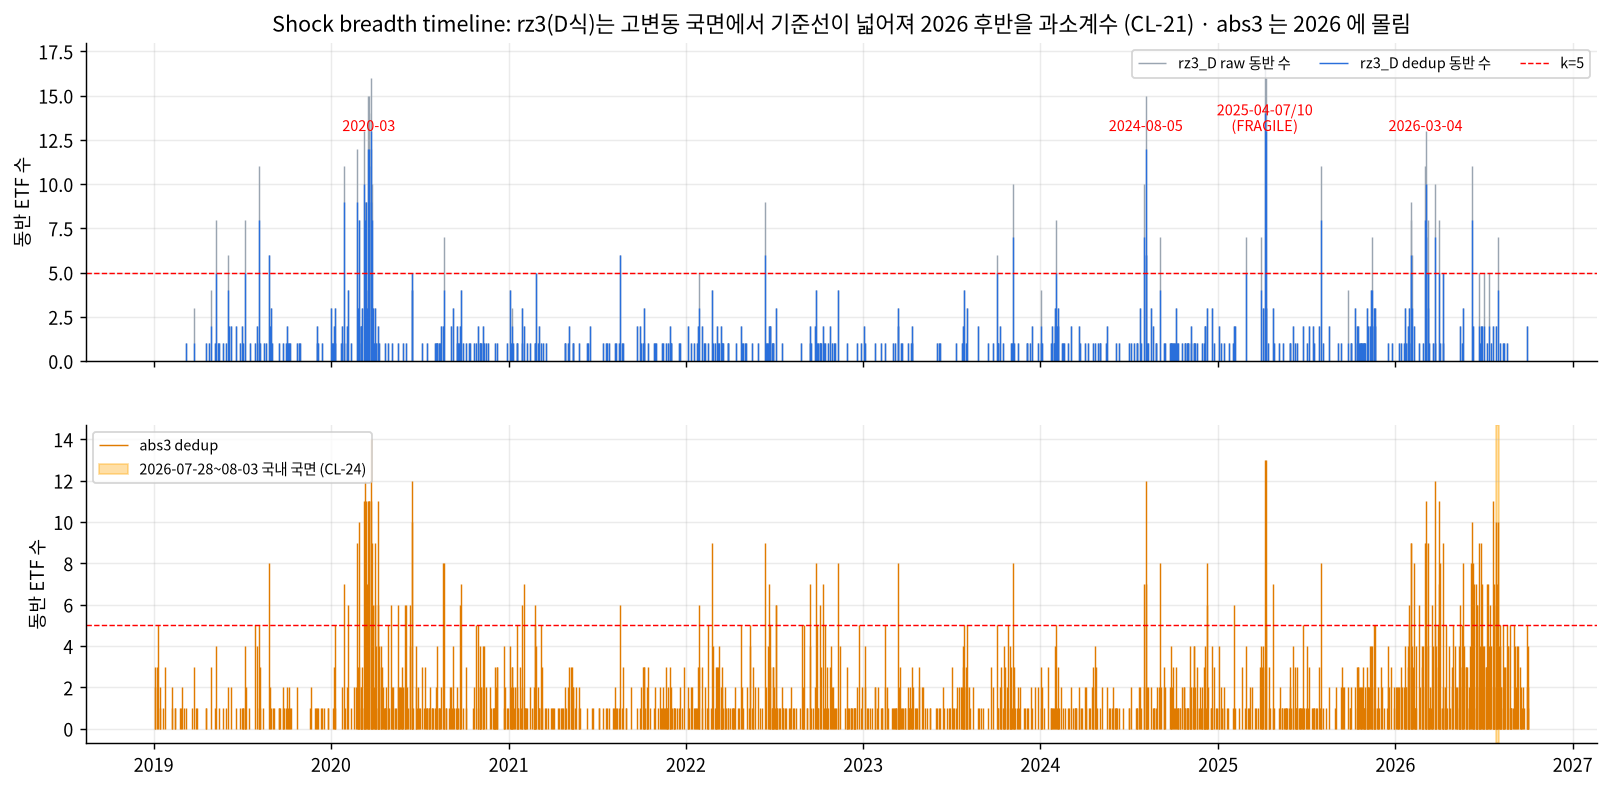

In [15]:
F("11_breadth_timeline.png")

**WHAT THIS FIGURE MEASURES** — 일별 동반 극단 ETF 수. 상단 rz3_D (회색 raw, 파랑 dedup), 하단 abs3 dedup. 빨간 점선 k=5.

**WHAT WE SEE** — (하단 주황 음영 = 2026-07-28~08-03 국내 국면, CL-24) rz3_D 는 2020-03, 2024-08-05, 2025-04-07/10, 2026-03-04 에 뾰족한 spike. abs3 는 2020-03 과 **2026 년 하반기에 밀집** — 2026 국내 고변동 국면의 매일이 절대 3% 를 넘는다. 같은 국면에서 rz3_D 는 기준선(MAD60)이 넓어져 거의 반응하지 않는다.

**WHY IT MATTERS FINANCIALLY** — breadth 의 시계열은 '공통 충격' 과 '고변동 국면' 을 구분하는 데 필요하다: 상대 기준은 놀라움을, 절대 기준은 크기를 센다.

**WHAT WE CANNOT CONCLUDE** — 동반 수는 동시성일 뿐 전염·인과가 아니다. 해외 ETF 의 KRX 종가는 기초시장 전일 움직임을 반영할 수 있어 '같은 날' 정렬이 사건 정렬과 다를 수 있다.

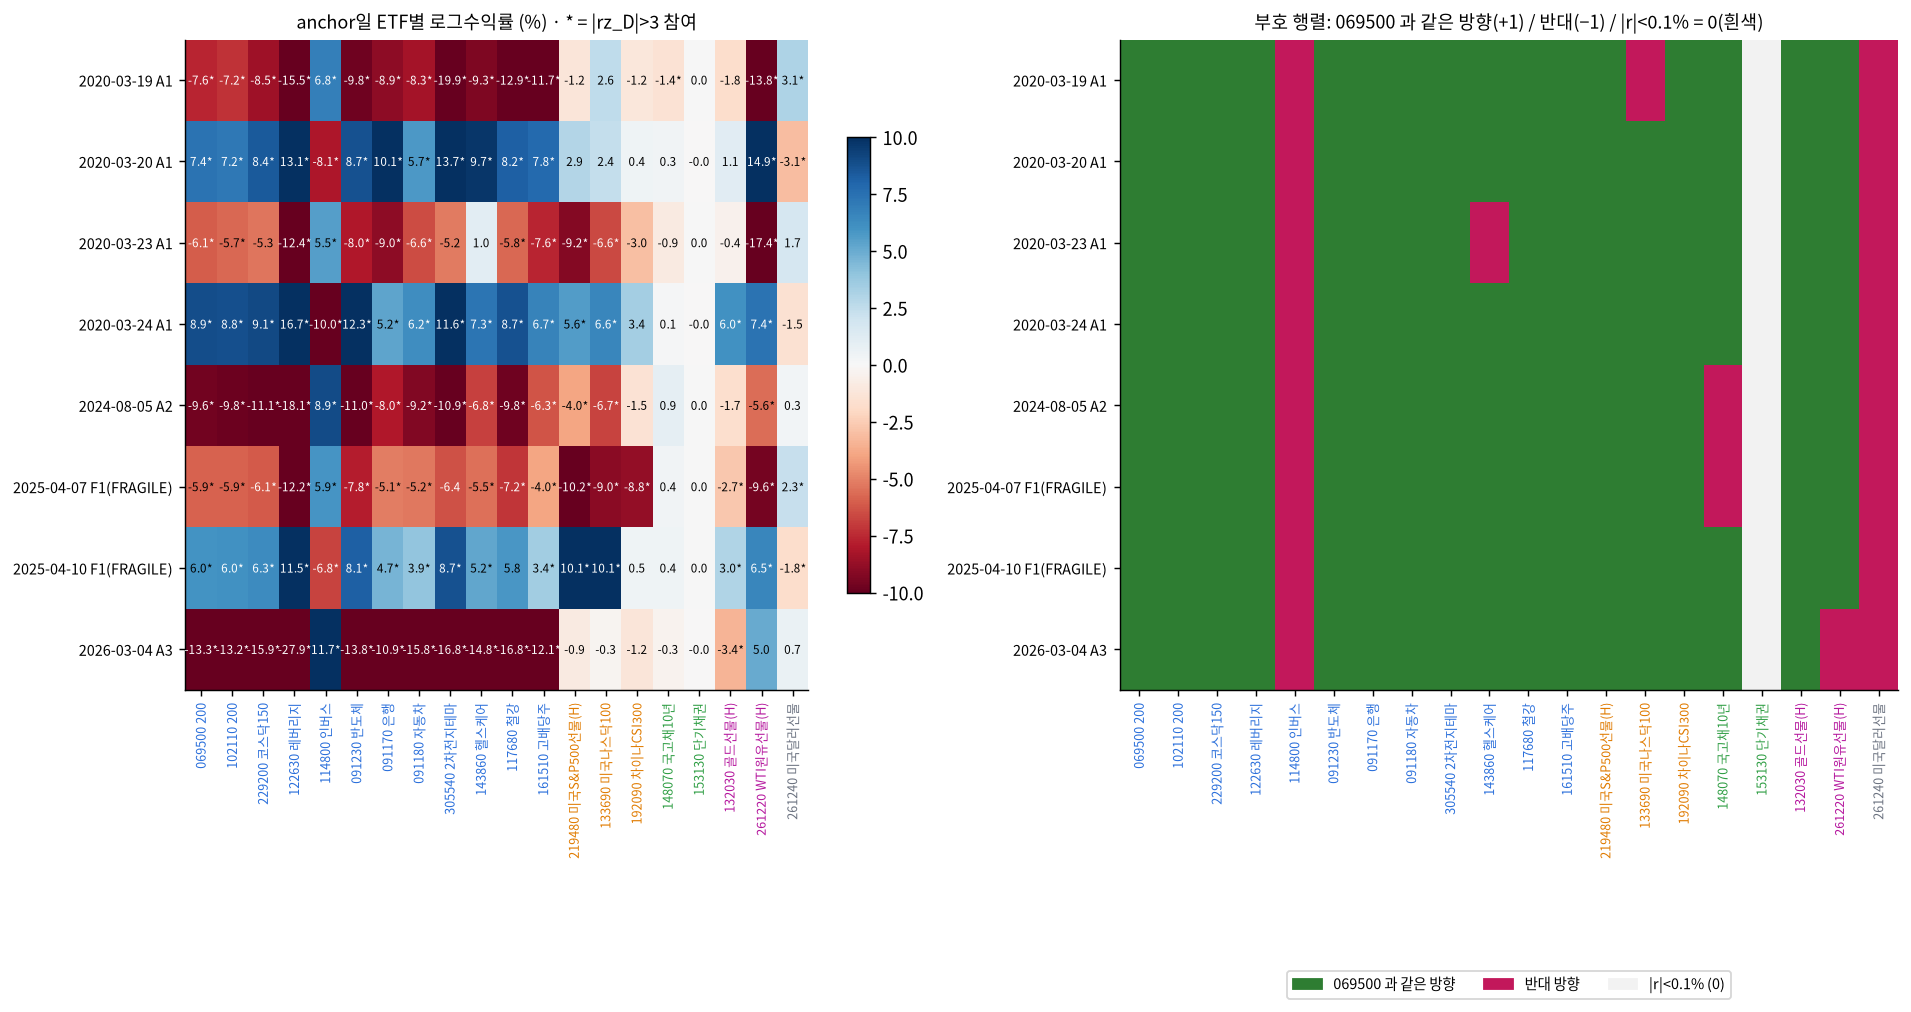

,date,anchor,r_069500_pct,n_rz3_D,n_rz3_D_dedup,n_rz3_A,n_rz3_A_dedup,n_q99,n_q99_dedup,n_abs3,n_abs3_dedup,n_same_sign_as_069500,n_opposite
0,2020-03-19,A1,-7.6014,15,12,15,12,15,12,14,11,16,3
1,2020-03-20,A1,7.4072,14,11,14,11,12,10,14,11,17,2
2,2020-03-23,A1,-6.0585,12,9,12,9,5,5,14,11,16,3
3,2020-03-24,A1,8.8763,16,13,15,12,13,10,17,14,17,2
4,2024-08-05,A2,-9.6271,15,12,16,13,13,10,15,12,16,3
5,2025-04-07,F1(FRAGILE),-5.8655,17,14,17,14,4,4,16,13,16,3
6,2025-04-10,F1(FRAGILE),5.9802,16,13,16,13,4,4,16,13,17,2
7,2026-03-04,A3,-13.3089,13,10,14,11,12,9,14,11,16,3


In [16]:
F("12_shock_participation_sign.png"); T("universe_shock_anchor_survival.csv")

**WHAT THIS FIGURE MEASURES** — anchor 일(행) × ETF(열). 왼쪽: 로그수익률 % (* = |rz_D|>3). 오른쪽: 069500 과의 부호 일치(+1)/반대(−1), |r|<0.1% 는 0. 표: 정의별 동반 수(raw/dedup).

**WHAT WE SEE** — 확정 anchor A1 2020-03-19~24 (rz3_D 12~16, dedup 9~13), A2 2024-08-05 (15/12, 069500 −9.6%), A3 2026-03-04 (13/10, 069500 −13.3%) — 네 정의 모두 k≥5 생존. 반대 부호 고정: 114800(기계적), 261240 달러(2020-03-19 +3.1%, 03-20 −3.1% 처럼 주식과 교대로 반대), 2024-08-05 에 148070 국고채 +0.9%. FRAGILE F1 2025-04-07/10: rz3_D 17/16, abs3 16/16 이지만 **q99 4/4** → k≥5 탈락 (CL-33). 2025-04 는 해외주식 219480/133690 이 −10%/+10% 로 국내보다 컸다.

**WHY IT MATTERS FINANCIALLY** — 공통 충격의 구조 = 주식 동반 + 달러 반대 + 채권·금 혼재 (CL-22, CL-27). '위기 헤지' 로 일관된 것은 데이터상 달러선물뿐.

**WHAT WE CANNOT CONCLUDE** — anchor 8일은 사례이지 표본이 아니다. 2025-04 F1 의 q99 탈락은 2026 고변동이 q99 를 끌어올린 탓으로 추정되나 미검증.

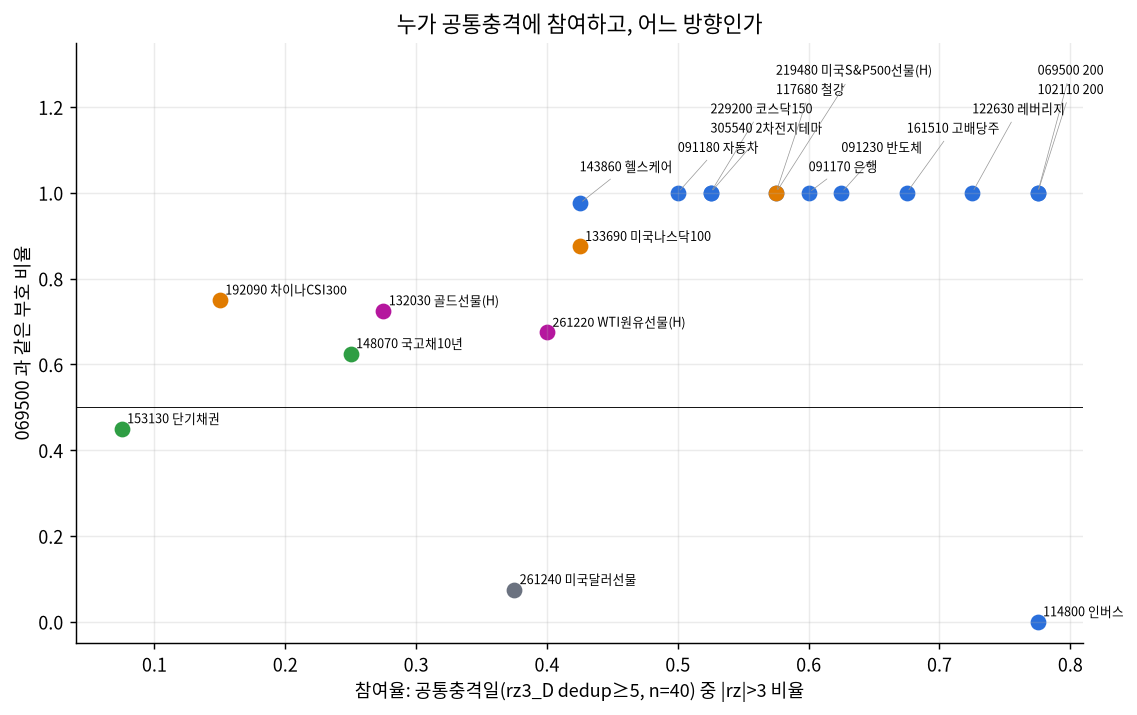

,participation_rate,same_sign_rate_vs_069500,mean_r_pct_on_down_days,asset_scope
153130,0.0750,0.4500,0.0017,bond
192090,0.1500,0.7500,-1.7834,foreign_equity
148070,0.2500,0.6250,-0.2474,bond
132030,0.2750,0.7250,-1.3179,commodity
261240,0.3750,0.0750,1.0577,fx
261220,0.4000,0.6750,-3.0752,commodity
133690,0.4250,0.8750,-2.6711,foreign_equity
143860,0.4250,0.9750,-4.5349,domestic_equity
091180,0.5000,1.0000,-5.1246,domestic_equity
229200,0.5250,1.0000,-5.7040,domestic_equity


In [17]:
F("13_shock_participation_scatter.png"); T("universe_shock_participation_by_etf.csv", index_col=0).sort_values("participation_rate")

**WHAT THIS FIGURE MEASURES** — 공통충격일(rz3_D dedup ≥5, n=40) 중 각 ETF 의 |rz|>3 참여율(x) 과 069500 과 같은 부호 비율(y).

**WHAT WE SEE** — 국내 지수형 참여율 0.73~0.78 · 같은 부호 1.00; 업종 0.43~0.68. 114800 참여 0.78 · 같은 부호 0 (기계적). 261240 참여 0.38 · 같은 부호 **0.075** (하락 공통일 평균 +1.06%). 192090 CSI300 0.15, 153130 0.075, 148070 0.25 (부호 0.63 — 일관된 반대 아님).

**WHY IT MATTERS FINANCIALLY** — 국내주식 충격의 '참여자' 와 '반대편' 이 명확히 갈린다: 반대편은 인버스(설계)와 달러(경제적)뿐. 국고채·금은 위기일 헤지로 일관되지 않다 (CL-27).

**WHAT WE CANNOT CONCLUDE** — 참여율은 rz3_D 정의에 종속. 공통일 표본 40일로 ETF 간 차이의 불확실성(CI)은 계산하지 않았다.

## 4b. 구조와 peer 의 직접 증거

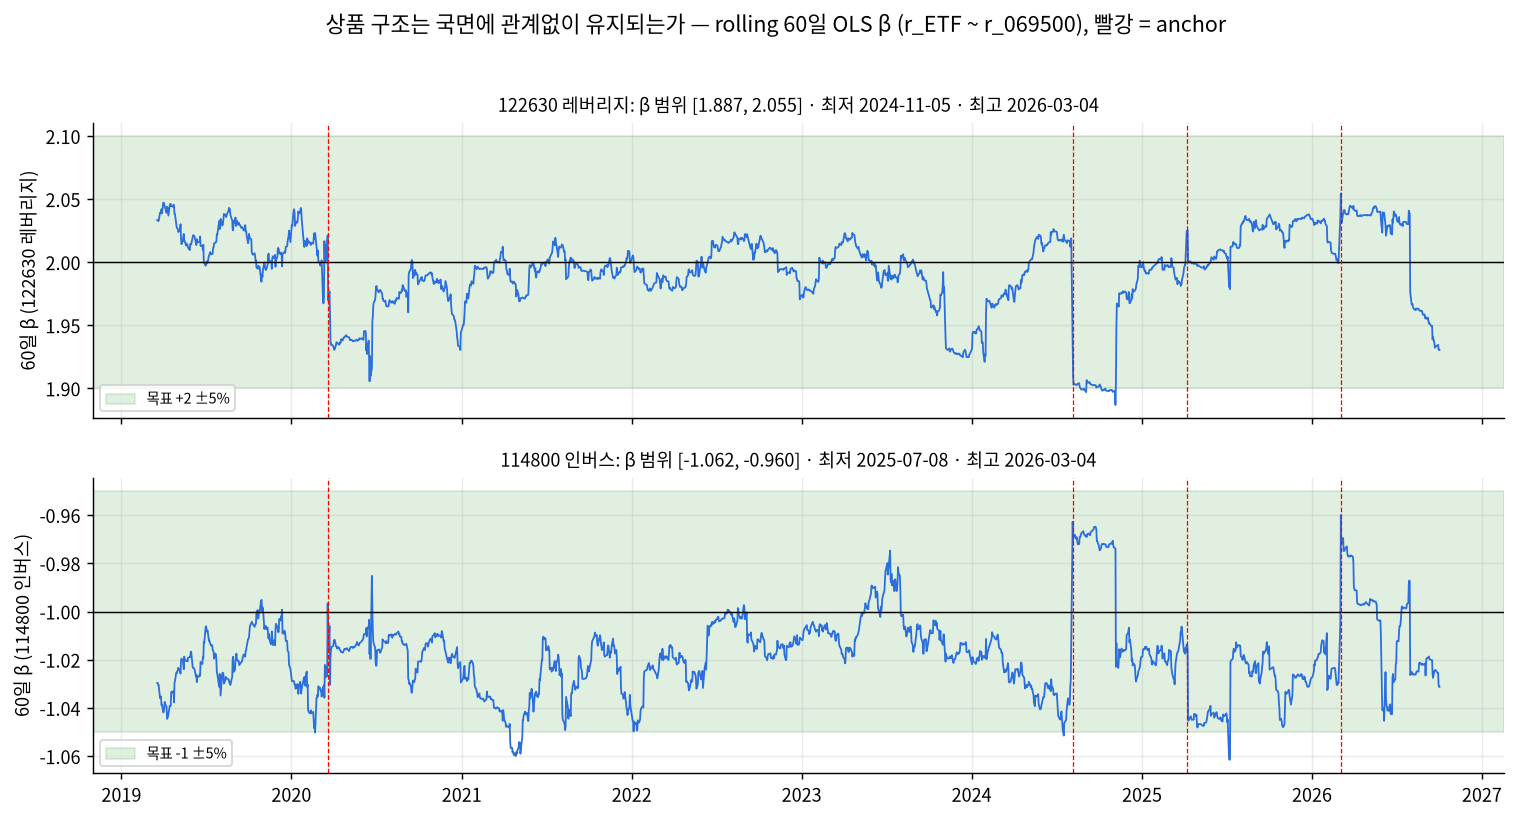

,beta60_122630,beta60_114800
count,"1,853.0000","1,853.0000"
mean,1.9939,-1.0182
std,0.0320,0.0168
min,1.8869,-1.0615
25%,1.9797,-1.0281
50%,1.9973,-1.0186
75%,2.0160,-1.0103
max,2.0545,-0.9600


In [18]:
F("16_rolling_beta_geared.png"); T("universe_rolling_beta60.csv", index_col=0).describe()

**WHAT THIS FIGURE MEASURES** — rolling 60일 OLS β (r_ETF ~ r_069500). 위: 122630 레버리지, 아래: 114800 인버스. 검은 선 = 설계 배율(+2/−1), 녹색 = ±5% 밴드, 빨간 점선 = shock anchor.

**WHAT WE SEE** — 레버리지 β 범위 **[1.887, 2.055]** (최저 2024-11-05), 인버스 **[−1.062, −0.960]** (가장 약한 값 2026-03-04 = A3 anchor 당일 포함 창). 전 기간 거의 ±5% 밴드 안.

**WHY IT MATTERS FINANCIALLY** — 일간 배율 설계는 국면(2020 위기, 2026 고변동)과 무관하게 유지된다. 따라서 geared ETF 는 독립 자산이 아니라 KOSPI200 factor 의 기계적 변환이며, breadth·PCA 에서 dedup 해야 한다.

**WHAT WE CANNOT CONCLUDE** — 일간 β 가 정확해도 다기간 수익률은 경로 의존(변동성 drag)이라 2배/−1배가 아니다. 60일 창의 β 편차가 추적오차인지 종가 체결 잡음인지는 NAV 없이 구분 불가.

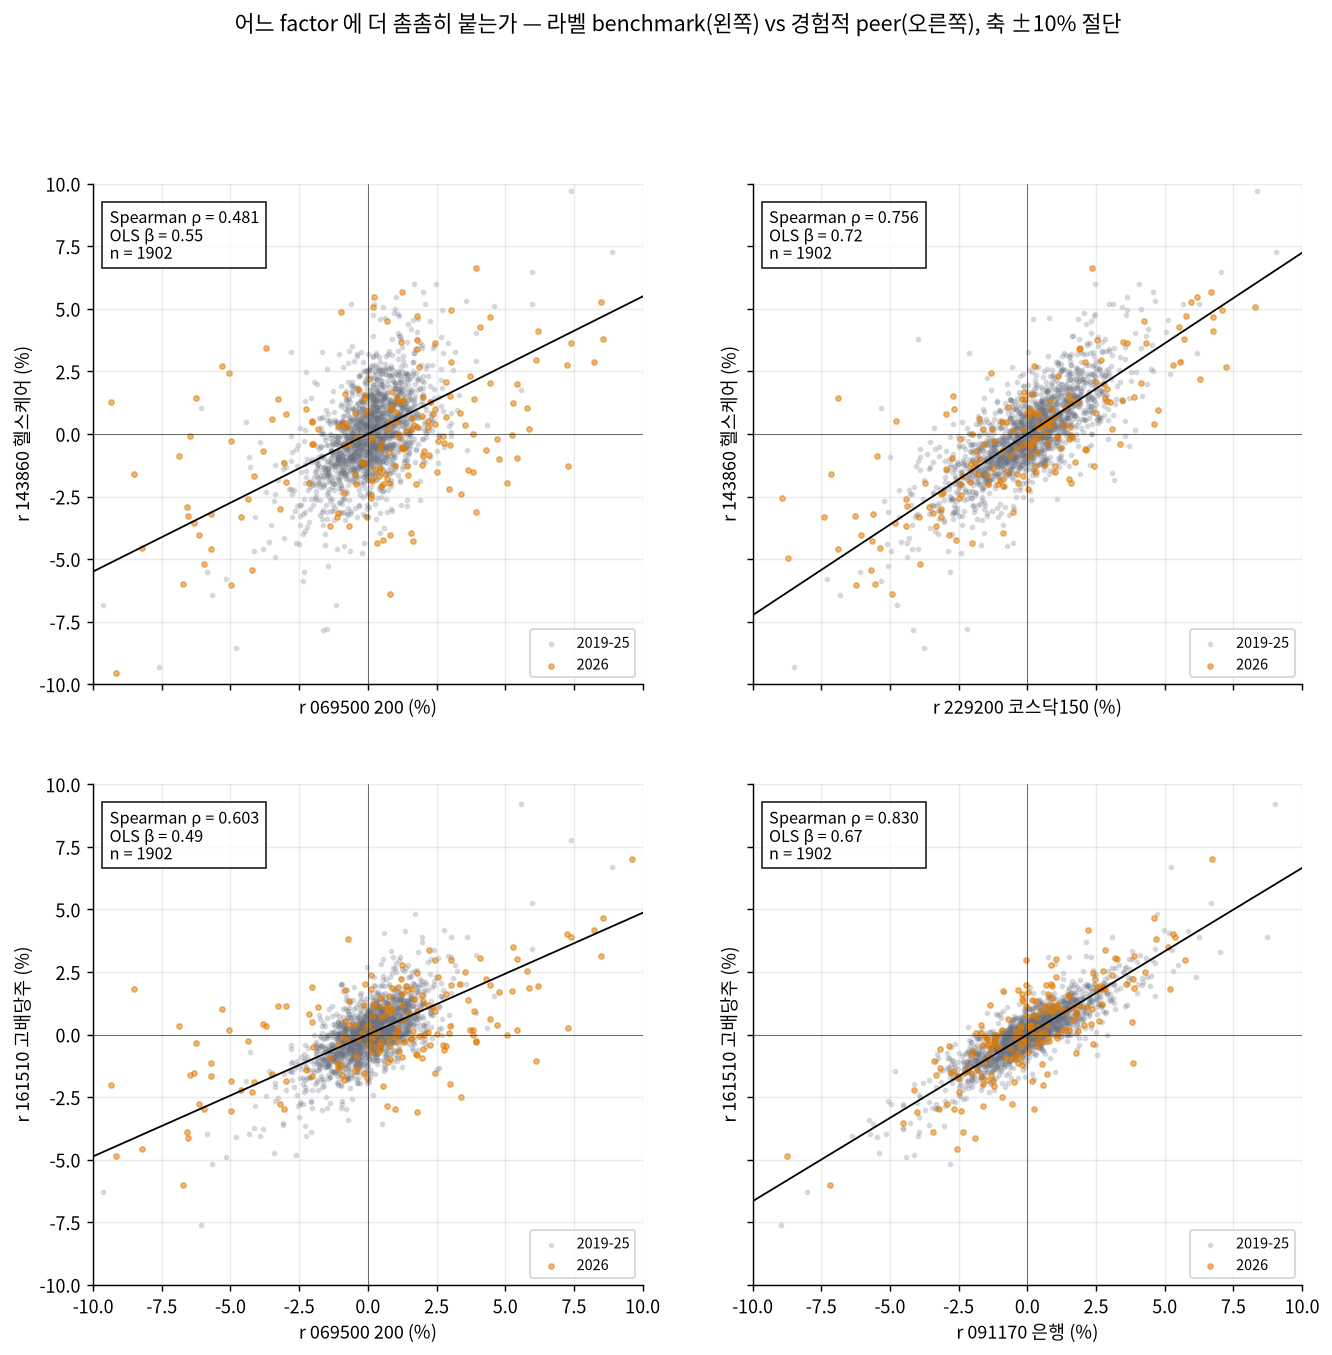

,share_delta_pos,min,min_date
143860:229200_vs_069500:60d,0.9639,-0.2095,2023-08-30
143860:229200_vs_069500:120d,0.9452,-0.0697,2023-08-01
161510:091170_vs_069500:60d,0.9520,-0.1619,2019-03-15
161510:091170_vs_069500:120d,0.9701,-0.0983,2019-05-31
305540:117680_vs_091230:60d,0.5310,-0.5148,2021-07-30
305540:117680_vs_091230:120d,0.5329,-0.4431,2021-08-09


In [19]:
F("17_empirical_peer_scatter.png"); T("universe_peer_stability.csv", index_col=0)

**WHAT THIS FIGURE MEASURES** — 일간수익률 산점도 (축 ±10% 절단). 위: 143860 헬스케어 vs 069500(왼쪽) / 229200 코스닥150(오른쪽). 아래: 161510 고배당 vs 069500 / 091170 은행. 주황 = 2026, 검은 선 = OLS 적합. 표: rolling Δρ>0 비율.

**WHAT WE SEE** — 오른쪽 패널의 점구름이 회귀선에 훨씬 밀착: 헬스케어 ρ 0.756·β 0.72 (코스닥150) vs 0.481·0.55 (KOSPI200), 고배당 ρ 0.830·β 0.67 (은행) vs 0.603·0.49. 2026 점(주황)도 같은 패턴 — 고변동 국면에서도 경험적 peer 가 더 가깝다.

**WHY IT MATTERS FINANCIALLY** — 상대수익률·고유충격을 계산할 benchmark 로 라벨 benchmark(KOSPI200) 대신 경험적 peer 를 쓰면 시장효과 제거가 더 정확해진다.

**WHAT WE CANNOT CONCLUDE** — 근접성의 원인(구성종목 중복 vs factor 공유)은 holdings 없이 판별 불가. ±10% 밖 극단일은 그림에서 잘린다 (통계량은 전체 n=1902).

## 5. Claim 재확인 표 (DOCX 대비)

In [20]:
T("universe_claim_checks.csv", index_col=0)

,pearson,spearman,n
069500~102110,0.9990,0.9978,"1,902.0000"
143860~229200,0.7877,0.7561,"1,902.0000"
143860~069500,0.5084,0.4807,"1,902.0000"
161510~091170,0.8619,0.8296,"1,902.0000"
161510~069500,0.6547,0.6028,"1,902.0000"
114800~069500,-0.9956,-0.9961,"1,902.0000"
261240~069500,-0.4577,-0.5193,"1,900.0000"
305540~117680,0.6191,0.5463,"1,902.0000"
305540~091230,0.5120,0.4596,"1,902.0000"
261220~069500_2019_25,0.2875,0.2359,"1,718.0000"


| DOCX claim | 재계산 | 판정 |
|---|---|---|
| KODEX200–TIGER200 corr ≈ 0.999, 일간차 sd ≈ 8bp | Pearson 0.9990 · Spearman 0.9978 · sd **8.05bp** | 일치 |
| leverage beta ≈ 1.99 / inverse ≈ −1.02 | **1.986 / −1.016** (OLS on 069500, Rt) | 일치 |
| 헬스케어는 KOSDAQ150 과 더 가깝다 (≈0.76) | Spearman 0.756 vs 069500 0.481, 차 점추정 +0.275 CI[0.23,0.32] | 일치 + CI 추가 |
| 고배당–은행 ≈ 0.83 | Spearman 0.830 vs 069500 0.603, 차 점추정 +0.227 CI[0.18,0.27] | 일치 + CI 추가 |
| 달러 KOSPI ≈ −0.52 | Spearman −0.519 · Pearson −0.458 (DQ 제외) | 일치 (척도 명시 필요) |
| 통계 군집 ≠ taxonomy | 114800·261240 signed 군집, 1−|ρ| 로 해소 | 일치 (CL-14) |
| 2026 vol 확대는 국내주식 집중 | 069500 3.3× (top3 제외 2.9×), 달러 1.26 (DQ 제외) vs 해외 0.73~0.94; **금 2.21배 [1.39,3.10] · WTI 1.50배 반례** (D) | **하향**: 'domestic equity + commodity, 해외주식 아님' |
| 달러 '주식 폭락일 86% 상승' | D: 정의별 0.72–0.91, 86% 재현 안 됨; 본 notebook 공통일(rz3_D dedup≥5, n=40) 같은 부호 0.075 → 반대 0.925 | **정의 명시 필수**, 단일 86% 인용 금지 |
| 군집 구조 | D: average/complete k=5 ROBUST, ward·2026 단독 FRAGILE; PC1 0.43–0.52 / dedup 0.39 | 조건부 |
| k≥5 공통일 52/22/175 | rz3_D 52 · q99 22 · abs3(log) **177** · rz3_A 61 | 거의 일치 (DOCX 175 = 단순수익률 기준) |
| 2025-04-07/10 FRAGILE | rz3 17/16, q99 4/4 | 일치 (CL-33) |
| 달러 이상치 제외 vol ≈ 9% | **8.9%** | 일치 |